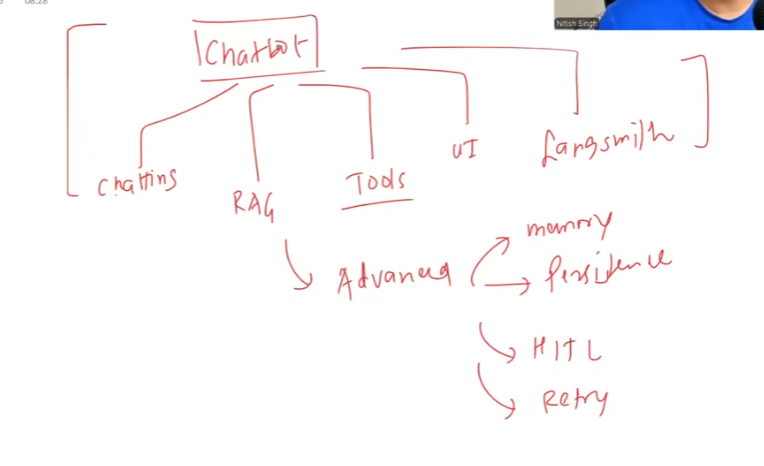

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from pydantic import BaseModel, Field

load_dotenv()

model = ChatOllama(
    model="llama3",  # or any model you have pulled
    temperature=0
) 

c:\Users\HP\Documents\Coding journeys\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langgraph.checkpoint.memory import MemorySaver


In [3]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state : ChatState):

    # take user query from state
    messages = state['messages']
    
    # send to llm
    response = model.invoke(messages)
    
    # response store state
    return {'messages' : [response]}

In [5]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# Add_nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)


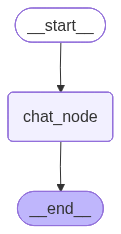

In [6]:
chatbot

In [9]:
thread_id = '1'

while True:
    user_message = input('Type Here : ')
    
    print('User:', user_message)
    
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    
    config = {'configurable' : {'thread_id' : thread_id}}
    response = chatbot.invoke({'messages' : [HumanMessage(content = user_message)]}, config=config)

    print('AI  : ', response['messages'][-1].content)
    

User: hello
AI  :  Hello! It's nice to meet you. Is there something I can help you with, or would you like to chat?
User: what is my name?
AI  :  I apologize, but I don't have any information about your name. As a conversational AI, I don't have personal knowledge of individuals or their names. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. Would you like to introduce yourself?
User: exit


In [10]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='1933d6c8-2aa8-4cb4-a80e-29f63c271a60'), AIMessage(content="Hello! It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3', 'created_at': '2026-05-31T09:39:01.7780386Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8763812100, 'load_duration': 6473963600, 'prompt_eval_count': 11, 'prompt_eval_duration': 337458100, 'eval_count': 26, 'eval_duration': 1924838900, 'logprobs': None, 'model_name': 'llama3', 'model_provider': 'ollama'}, id='lc_run--019e7d66-8bd3-7540-a1a2-202225cf459f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 26, 'total_tokens': 37}), HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='b55542cf-5b1e-4503-9219-47744460f65e'), AIMessage(content="I apologize, but I don't have a